## 0. Importing PyTorch and setting up device-agnostic code

In [1]:
import torch
from torch import nn
torch.__version__

'2.7.0+cu126'

In [2]:
# Setup device-agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

## 1. Get data

In [4]:
import requests
import zipfile
from pathlib import Path

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

# If the image folder doesn't exist, download it and prepare it...
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)

    # Download pizza, steak, sushi data
    with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        print("Downloading pizza, steak, sushi data...")
        f.write(request.content)

    # Unzip pizza, steak, sushi data
    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
        print("Unzipping pizza, steak, sushi data...")
        zip_ref.extractall(image_path)

data/pizza_steak_sushi directory exists.


## 2. Become one with the data (data preparation)

In [5]:
import os
def walk_through_dir(dir_path):
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

In [6]:
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data/pizza_steak_sushi'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/test'.
There are 0 directories and 25 images in 'data/pizza_steak_sushi/test/pizza'.
There are 0 directories and 19 images in 'data/pizza_steak_sushi/test/steak'.
There are 0 directories and 31 images in 'data/pizza_steak_sushi/test/sushi'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/train'.
There are 0 directories and 78 images in 'data/pizza_steak_sushi/train/pizza'.
There are 0 directories and 75 images in 'data/pizza_steak_sushi/train/steak'.
There are 0 directories and 72 images in 'data/pizza_steak_sushi/train/sushi'.


In [7]:
train_dir = image_path/'train'
test_dir = image_path/'test'

train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

##  2.1 Visualize an image

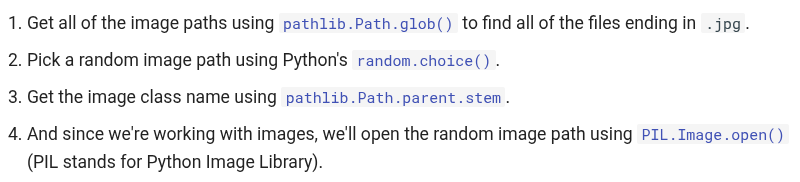

Random image path: data/pizza_steak_sushi/test/sushi/2394442.jpg
Image class: sushi
Image height: 408
Image width: 512


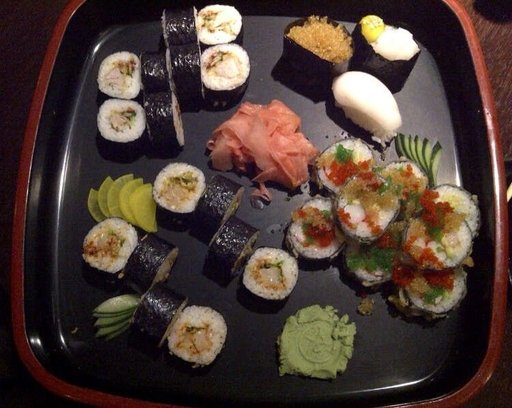

In [8]:
import random
from PIL import Image

random.seed(42)

image_path_list = list(image_path.glob('*/*/*.jpg'))
random_image_path = random.choice(image_path_list)
image_class = random_image_path.parent.stem
img = Image.open(random_image_path)

print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img

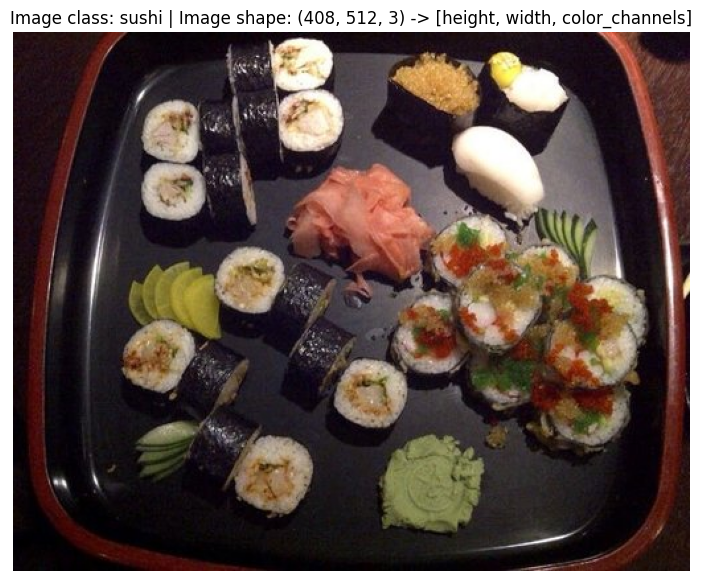

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Turn the image into an array
img_as_array = np.asarray(img)

# Plot the image with matplotlib
plt.figure(figsize=(10, 7))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shape: {img_as_array.shape} -> [height, width, color_channels]")
plt.axis(False);

## 3. Transforming data

In [10]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torchvision.transforms.functional as TF

### 3.1 Transforming data with torchvision.transforms

In [53]:
# Improved data transforms for food classification
train_transform = transforms.Compose([
    # === PIL IMAGE TRANSFORMS (applied to PIL Images) ===
    # Resize to standard CNN input size (224x224 for better performance)
    transforms.Resize(size=(224, 224), interpolation=transforms.InterpolationMode.BILINEAR),

    # Data augmentation suitable for food images
    transforms.RandomHorizontalFlip(p=0.5),  # Food can be flipped horizontally
    transforms.RandomRotation(degrees=15),    # Slight rotation for variety
    
    # Color augmentations (important for food differentiation)
    transforms.ColorJitter(
        brightness=0.2,    # Lighting conditions in food photos
        contrast=0.2,      # Different camera/lighting setups
        saturation=0.2,    # Food color intensity variations
        hue=0.1           # Slight color variations
    ),

    # Geometric transformations for robustness
    transforms.RandomPerspective(distortion_scale=0.1, p=0.3),
    
    # Random crop for scale invariance (food items at different scales)
    transforms.RandomResizedCrop(
        size=(224, 224),
        scale=(0.8, 1.0),   # Keep most of the image
        ratio=(0.9, 1.1)    # Maintain aspect ratio close to square
    ),

    # === CONVERT TO TENSOR ===
    transforms.ToTensor(),  # Converts PIL to tensor and normalizes to [0,1]

    # Normalize with ImageNet statistics (works well for food images)
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # ImageNet mean (RGB)
        std=[0.229, 0.224, 0.225]    # ImageNet std (RGB)
    )
])

# Separate transform for test data (no augmentation)
test_transform = transforms.Compose([
    transforms.Resize(size=(224, 224), interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [54]:
def plot_transformed_images(image_paths, transform, n=3, seed=42):
    random.seed(seed)
    random_image_paths = random.sample(image_paths, k=n)

    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(1, 2, figsize=(12, 6))

            # Original image
            ax[0].imshow(f)
            ax[0].set_title(f"Original \nSize: {f.size}")
            ax[0].axis("off")

            # Transform and plot image
            transformed_tensor = transform(f)

            # Convert tensor back to displayable format
            # First denormalize the tensor
            denormalize = transforms.Normalize(
                mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
                std=[1/0.229, 1/0.224, 1/0.225]
            )

            # Denormalize and clamp to [0,1] range
            display_tensor = denormalize(transformed_tensor)
            display_tensor = torch.clamp(display_tensor, 0, 1)

            # Convert to matplotlib format [H, W, C]
            transformed_image = display_tensor.permute(1, 2, 0)

            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed \nSize: {transformed_image.shape}")
            ax[1].axis("off")

            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)
            plt.tight_layout()
            plt.show()

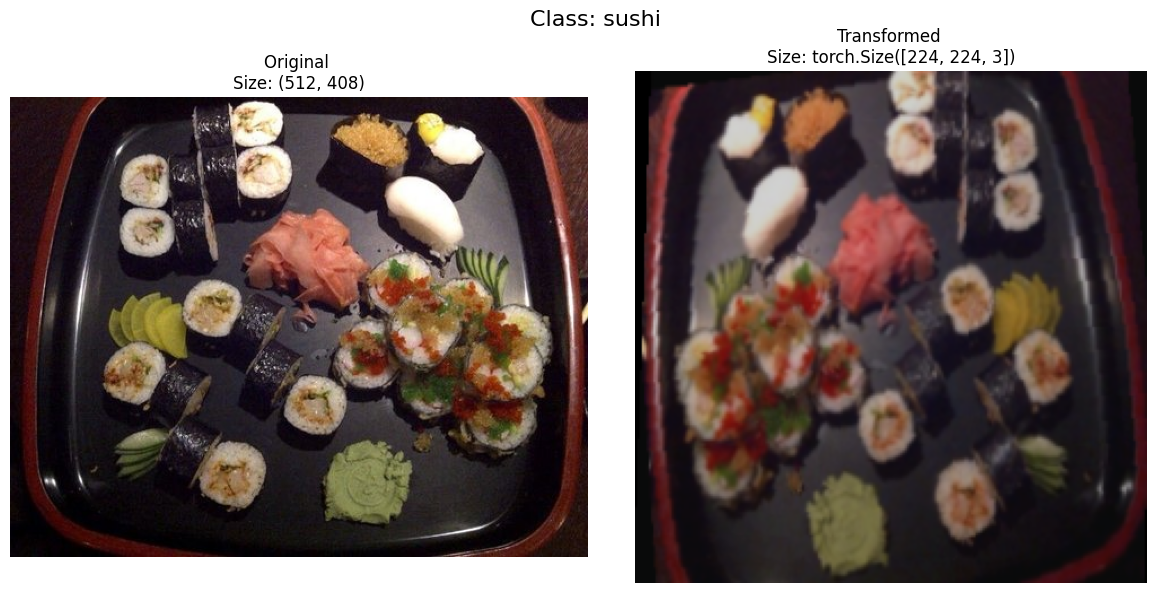

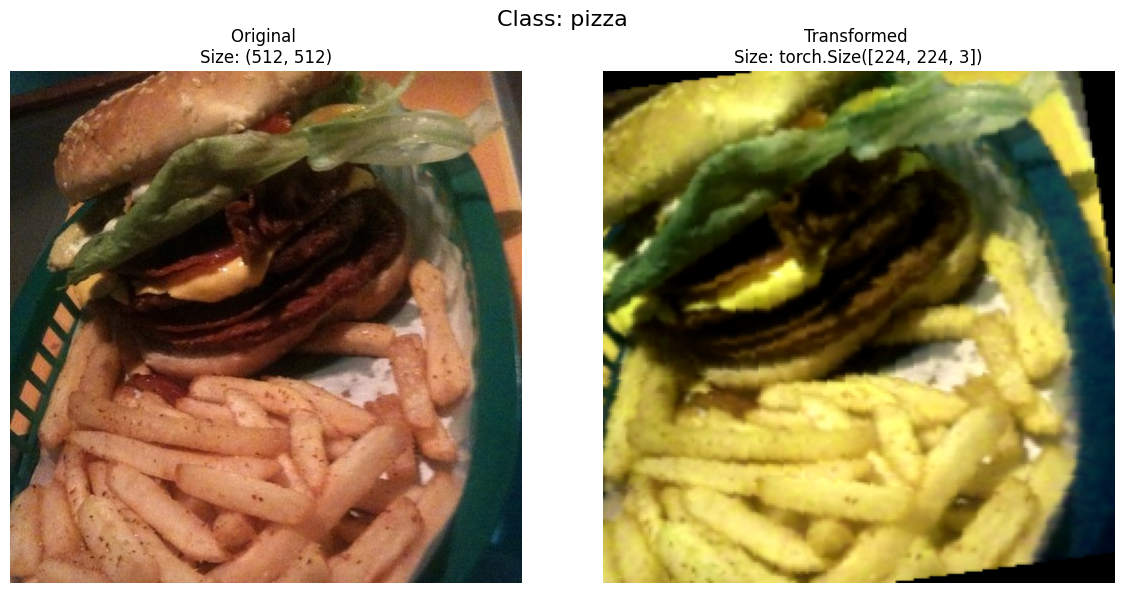

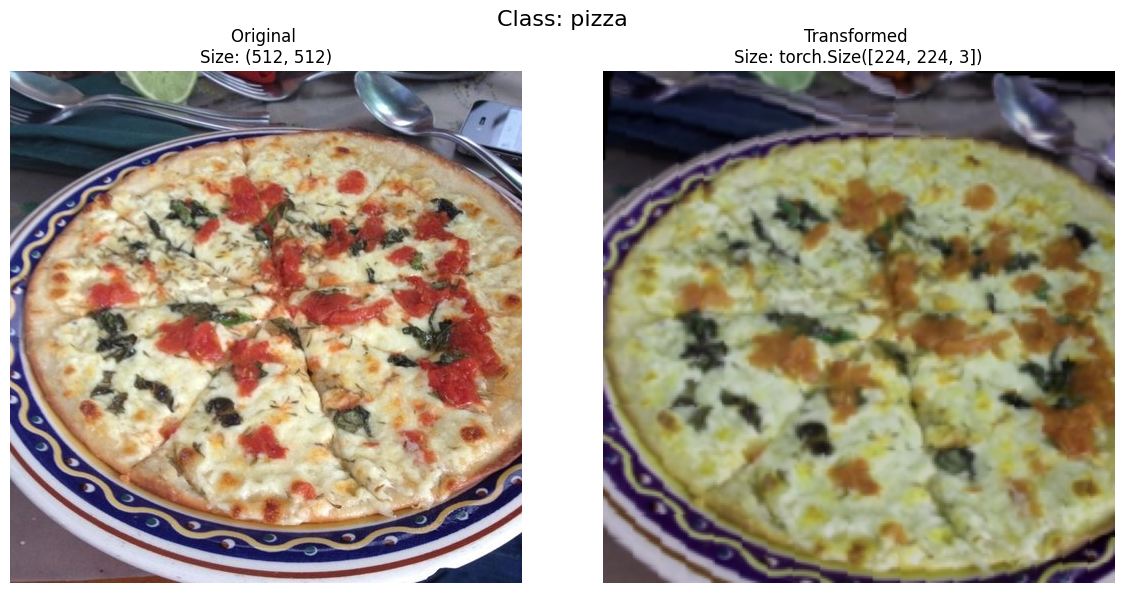

In [55]:
plot_transformed_images(image_path_list,
                        transform=train_transform,
                        n=3)

## 4. Option 1: Loading Image Data Using ImageFolder

In [56]:
train_data = datasets.ImageFolder(
    root=train_dir,
    transform=train_transform,
    target_transform=None
)
test_data = datasets.ImageFolder(
    root=test_dir,
    transform=test_transform
)
print(f"Train data:\n{train_data}\nTest data:\n{test_data}")

Train data:
Dataset ImageFolder
    Number of datapoints: 225
    Root location: data/pizza_steak_sushi/train
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
               ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.1, 0.1))
               RandomPerspective(p=0.3)
               RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0), ratio=(0.9, 1.1), interpolation=bilinear, antialias=True)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )
Test data:
Dataset ImageFolder
    Number of datapoints: 75
    Root location: data/pizza_steak_sushi/test
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_s

In [57]:
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [58]:
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [59]:
# Check the lengths
len(train_data), len(test_data)

(225, 75)

In [60]:
img, label = train_data[0][0], train_data[0][1]
print(f"Image tensor:\n{img}")
print(f"Image shape: {img.shape}")
print(f"Image datatype: {img.dtype}")
print(f"Image label: {label}")
print(f"Label datatype: {type(label)}")

Image tensor:
tensor([[[-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-1.9638, -1.9638, -1.9638,  ..., -2.1179, -2.1179, -2.1179],
         ...,
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179]],

        [[-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-1.9132, -1.9132, -1.9307,  ..., -2.0357, -2.0357, -2.0357],
         ...,
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357]],

        [[-1.8044, -1.8044, -1.8044,  ..., -1.8044, -1.8044, -1.8044],
         [-1.8044, -1.8044, -1.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.0125492].


Original shape: torch.Size([3, 224, 224]) -> [color_channels, height, width]
Image permute shape: torch.Size([224, 224, 3]) -> [height, width, color_channels]


Text(0.5, 1.0, 'pizza')

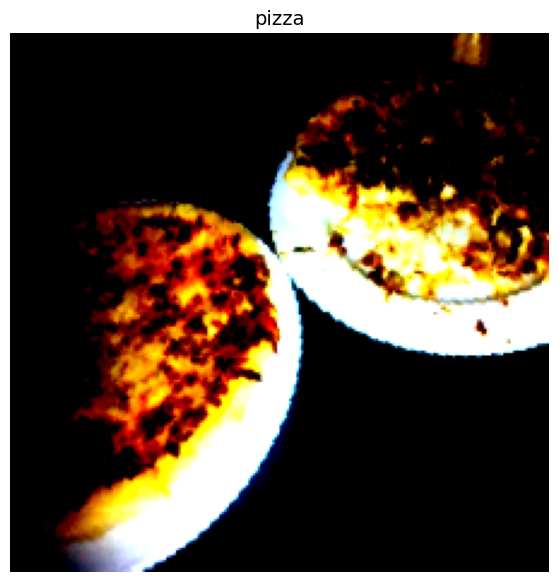

In [62]:
# Rearrange the order of dimensions
img_permute = img.permute(1, 2, 0)

# Print out different shapes (before and after permute)
print(f"Original shape: {img.shape} -> [color_channels, height, width]")
print(f"Image permute shape: {img_permute.shape} -> [height, width, color_channels]")

# Plot the image
plt.figure(figsize=(10, 7))
plt.imshow(img.permute(1, 2, 0))
plt.axis("off")
plt.title(class_names[label], fontsize=14)

### 4.1 Turn loaded images into DataLoader's

In [63]:
train_dataloader = DataLoader(
    dataset=train_data,
    batch_size=32,  # Increased batch size for BatchNorm
    num_workers=1,
    shuffle=True
)
test_dataloader = DataLoader(
    dataset=test_data,
    batch_size=32,  # Increased batch size for BatchNorm
    num_workers=1,
    shuffle=False
)
train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x715911ef2610>,
 <torch.utils.data.dataloader.DataLoader at 0x71590814b790>)

In [64]:
img, label = next(iter(train_dataloader))

# Batch size will now be 1, try changing the batch_size parameter above and see what happens
print(f"Image shape: {img.shape} -> [batch_size, color_channels, height, width]")
print(f"Label shape: {label.shape}")

Image shape: torch.Size([32, 3, 224, 224]) -> [batch_size, color_channels, height, width]
Label shape: torch.Size([32])


## 5. Option 2: Loading Image Data with a Custom Dataset

In [67]:
import os
import pathlib

from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple, Dict, List

In [68]:
# Instance of torchvision.datasets.ImageFolder()
train_data.classes, train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

### 5.1 Creating a helper function to get class names

In [69]:
# Setup path for target directory
target_directory = train_dir
print(f"Target directory: {target_directory}")

# Get the class names from the target directory
class_names_found = sorted([entry.name for entry in list(os.scandir(image_path / "train"))])
print(f"Class names found: {class_names_found}")

Target directory: data/pizza_steak_sushi/train
Class names found: ['pizza', 'steak', 'sushi']


In [70]:
# Make function to find classes in target directory
def find_classes(directory: str) -> Tuple[List[str], Dict[str, int]]:

    # 1. Get the class names by scanning the target directory
    classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())

    # 2. Raise an error if class names not found
    if not classes:
        raise FileNotFoundError(f"Couldn't find any classes in {directory}.")

    # 3. Create a dictionary of index labels (computers prefer numerical rather than string labels)
    class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
    return classes, class_to_idx

In [71]:
find_classes(train_dir)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

### 5.2 Create a custom Dataset to replicate ImageFolder

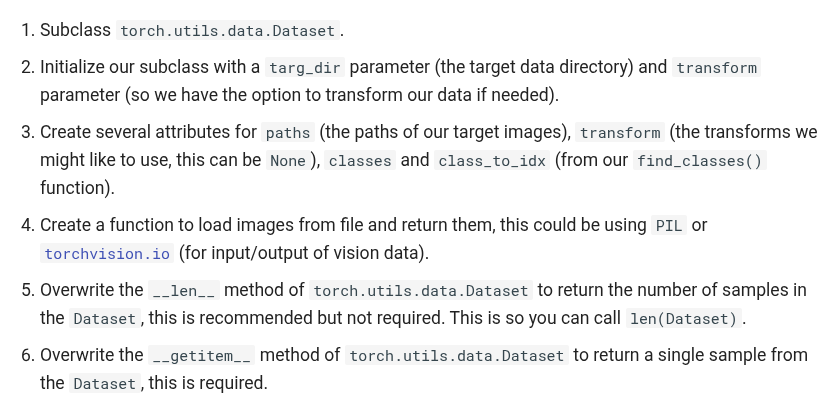

In [ ]:
from torch.utils.data import Dataset

# 1. Subclass torch.utils.data.Dataset
class ImageFolderCustom(Dataset):
    # 2. Initialize with a targ_dir and transform (optional) parameter
    def __init__(self, targ_dir: str, transform=None) -> None:
        # 3. Create class attributes
        # Get all image paths
        self.paths = list(pathlib.Path(targ_dir).glob("*/*.jpg")) 
        # Setup transforms
        self.transform = transform
        # Create classes and class_to_idx attributes
        self.classes, self.class_to_idx = find_classes(targ_dir)

    # 4. Make function to load images
    def load_image(self, index: int) -> Image.Image:
        "Opens an image via a path and returns it."
        image_path = self.paths[index]
        return Image.open(image_path)

    # 5. Overwrite the __len__() method (optional but recommended for subclasses of torch.utils.data.Dataset)
    def __len__(self) -> int:
        "Returns the total number of samples."
        return len(self.paths)

    # 6. Overwrite the __getitem__() method (required for subclasses of torch.utils.data.Dataset)
    def __getitem__(self, index: int) -> Tuple[torch.Tensor, int]:
        "Returns one sample of data, data and label (X, y)."
        img = self.load_image(index)
        class_name  = self.paths[index].parent.name # expects path in data_folder/class_name/image.jpeg
        class_idx = self.class_to_idx[class_name]

        # Transform if necessary
        if self.transform:
            return self.transform(img), class_idx # return data, label (X, y)
        else:
            return img, class_idx # return data, label (X, y)

In [73]:
train_data_custom = ImageFolderCustom(targ_dir=train_dir,
                                      transform=train_transform)
test_data_custom = ImageFolderCustom(targ_dir=test_dir,
                                     transform=test_transform)
train_data_custom, test_data_custom

(<__main__.ImageFolderCustom at 0x7159115a5dd0>,
 <__main__.ImageFolderCustom at 0x715911598490>)

In [30]:
len(train_data_custom), len(test_data_custom)

(225, 75)

In [31]:
train_data_custom.classes

['pizza', 'steak', 'sushi']

In [32]:
train_data_custom.class_to_idx

{'pizza': 0, 'steak': 1, 'sushi': 2}

## 5.3 Create a function to display random images

In [65]:
# 1. Take in a Dataset as well as a list of class names
def display_random_images(dataset: torch.utils.data.dataset.Dataset,
                          classes: List[str] = None,
                          n: int = 10,
                          display_shape: bool = True,
                          seed: int = None):

    # 2. Adjust display if n too high
    if n > 10:
        n = 10
        display_shape = False
        print(f"For display purposes, n shouldn't be larger than 10, setting to 10 and removing shape display.")

    # 3. Set random seed
    if seed:
        random.seed(seed)

    # 4. Get random sample indexes
    random_samples_idx = random.sample(range(len(dataset)), k=n)

    # 5. Setup plot
    plt.figure(figsize=(16, 8))

    # 6. Loop through samples and display random samples
    for i, targ_sample in enumerate(random_samples_idx):
        targ_image, targ_label = dataset[targ_sample][0], dataset[targ_sample][1]

        # 7. Adjust image tensor shape for plotting: [color_channels, height, width] -> [color_channels, height, width]
        targ_image_adjust = targ_image.permute(1, 2, 0)

        # Plot adjusted samples
        plt.subplot(1, n, i+1)
        plt.imshow(targ_image_adjust)
        plt.axis("off")
        if classes:
            title = f"class: {classes[targ_label]}"
            if display_shape:
                title = title + f"\nshape: {targ_image_adjust.shape}"
        plt.title(title)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2042704].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.3502399].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.3502399].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0151556..0.95798326].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0151556..0.95798326].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.8158263].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..

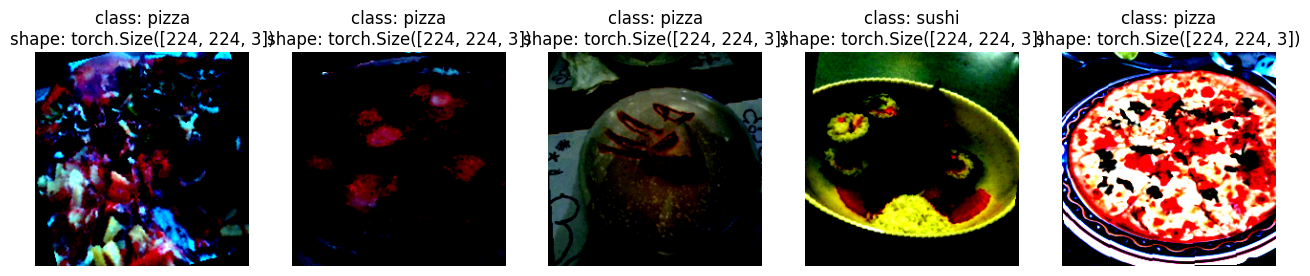

In [66]:
# Display random images from ImageFolder created Dataset
display_random_images(train_data,
                      n=5,
                      classes=class_names,
                      seed=None)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7925336..2.2042704].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9295317..1.9033613].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..1.8158263].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..1.8158263].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.0996952].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.0996952].

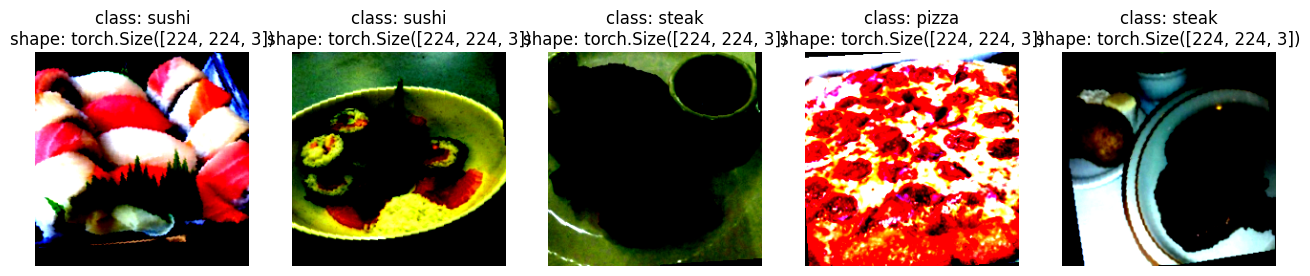

In [74]:
# Display random images from ImageFolderCustom Dataset
display_random_images(train_data_custom,
                      n=5,
                      classes=class_names,
                      seed=None) # Try setting the seed for reproducible images

## 5.4 Turn custom loaded images into DataLoader's

In [75]:
train_dataloader_custom = DataLoader(dataset=train_data_custom, # use custom created train Dataset
                                     batch_size=32, # how many samples per batch?
                                     num_workers=0, # how many subprocesses to use for data loading? (higher = more)
                                     shuffle=True) # shuffle the data?

test_dataloader_custom = DataLoader(dataset=test_data_custom, # use custom created test Dataset
                                    batch_size=32,
                                    num_workers=0,
                                    shuffle=False) # don't usually need to shuffle testing data

train_dataloader_custom, test_dataloader_custom

(<torch.utils.data.dataloader.DataLoader at 0x7159120e1e50>,
 <torch.utils.data.dataloader.DataLoader at 0x71591161a050>)

In [76]:
# Get image and label from custom DataLoader
img_custom, label_custom = next(iter(train_dataloader_custom))

# Batch size will now be 1, try changing the batch_size parameter above and see what happens
print(f"Image shape: {img_custom.shape} -> [batch_size, color_channels, height, width]")
print(f"Label shape: {label_custom.shape}")

Image shape: torch.Size([32, 3, 224, 224]) -> [batch_size, color_channels, height, width]
Label shape: torch.Size([32])


# 6. Building a Custom CNN Model for Food Classification

Now that we have our data loaded and preprocessed, let's build a custom Convolutional Neural Network (CNN) to classify our food images into three categories: pizza, steak, and sushi.

## 6.1 Creating a Custom CNN Architecture

In [ ]:
class FoodVisionCNN(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        
        # First convolutional block - Feature detection
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, 
                     out_channels=hidden_units, 
                     kernel_size=7, 
                     stride=2, 
                     padding=3),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )
        
        # Second convolutional block
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units*2, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units*2),
            nn.ReLU(),
            nn.Conv2d(hidden_units*2, hidden_units*2, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units*2),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        # Third convolutional block
        self.conv_block_3 = nn.Sequential(
            nn.Conv2d(hidden_units*2, hidden_units*4, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units*4),
            nn.ReLU(),
            nn.Conv2d(hidden_units*4, hidden_units*4, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units*4),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        # Fourth convolutional block - Deep feature extraction
        self.conv_block_4 = nn.Sequential(
            nn.Conv2d(hidden_units*4, hidden_units*8, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units*8),
            nn.ReLU(),
            nn.Conv2d(hidden_units*8, hidden_units*8, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units*8),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        # Adaptive pooling
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))
        
        # Enhanced classifier with better regularization (without BatchNorm1d to avoid batch size issues)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.6),
            nn.Linear(in_features=hidden_units*8*4*4, 
                     out_features=hidden_units*4),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(in_features=hidden_units*4, 
                     out_features=hidden_units*2),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(in_features=hidden_units*2, 
                     out_features=output_shape)
        )
    
    def forward(self, x: torch.Tensor):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.conv_block_3(x)
        
        x = self.conv_block_4(x)
        x = self.adaptive_pool(x)
        x = self.classifier(x)
        return x

In [78]:
# Create an instance of our model
torch.manual_seed(42)

# Model parameters
NUM_CLASSES = len(class_names)  # pizza, steak, sushi = 3 classes
INPUT_CHANNELS = 3  # RGB images
HIDDEN_UNITS = 32

# Create model instance
model = FoodVisionCNN(input_shape=INPUT_CHANNELS, 
                      hidden_units=HIDDEN_UNITS, 
                      output_shape=NUM_CLASSES)

print(f"Model: {model}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Class names: {class_names}")

Model: FoodVisionCNN(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2)

In [49]:
# Test the model with a sample batch
# Get a batch from our DataLoader
sample_batch, sample_labels = next(iter(train_dataloader))

print(f"Sample batch shape: {sample_batch.shape}")
print(f"Sample labels shape: {sample_labels.shape}")
print(f"Sample labels: {sample_labels}")

# Test model forward pass
model.eval()
with torch.inference_mode():
    y_logits = model(sample_batch)
    
print(f"\nModel output shape: {y_logits.shape}")
print(f"Model output (logits): {y_logits}")

# Convert logits to prediction probabilities
y_pred_probs = torch.softmax(y_logits, dim=1)
print(f"Prediction probabilities: {y_pred_probs}")

# Convert probabilities to prediction labels
y_pred_labels = torch.argmax(y_pred_probs, dim=1)
print(f"Predicted labels: {y_pred_labels}")

Sample batch shape: torch.Size([32, 3, 64, 64])
Sample labels shape: torch.Size([32])
Sample labels: tensor([0, 2, 0, 0, 1, 1, 0, 0, 1, 1, 1, 2, 0, 1, 0, 1, 0, 2, 0, 0, 0, 1, 2, 1,
        2, 1, 0, 1, 1, 0, 2, 2])

Model output shape: torch.Size([32, 3])
Model output (logits): tensor([[ 0.1015,  0.1076, -0.1472],
        [ 0.1013,  0.1078, -0.1472],
        [ 0.1011,  0.1077, -0.1471],
        [ 0.1014,  0.1078, -0.1471],
        [ 0.1014,  0.1079, -0.1471],
        [ 0.1012,  0.1079, -0.1473],
        [ 0.1020,  0.1075, -0.1474],
        [ 0.1004,  0.1072, -0.1488],
        [ 0.1013,  0.1075, -0.1473],
        [ 0.1013,  0.1077, -0.1472],
        [ 0.1011,  0.1077, -0.1474],
        [ 0.1012,  0.1078, -0.1471],
        [ 0.1006,  0.1071, -0.1487],
        [ 0.1014,  0.1073, -0.1479],
        [ 0.1012,  0.1074, -0.1473],
        [ 0.1013,  0.1077, -0.1472],
        [ 0.1012,  0.1078, -0.1473],
        [ 0.1013,  0.1075, -0.1471],
        [ 0.1013,  0.1078, -0.1473],
        [ 0.1010,  

## 6.2 Training the CNN Model

Now let's set up the training process for our custom CNN model. We'll create training and evaluation functions and then train the model.

In [79]:
from tqdm.auto import tqdm
from typing import Dict, List, Tuple

def train_step(model: torch.nn.Module, 
               dataloader: torch.utils.data.DataLoader, 
               loss_fn: torch.nn.Module, 
               optimizer: torch.optim.Optimizer,
               device: torch.device) -> Tuple[float, float]:
    
    # Put model in training mode
    model.train()

    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0

    # Loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):
        # Send data to target device
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate  and accumulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Calculate and accumulate accuracy metric across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch 
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

def test_step(model: torch.nn.Module, 
              dataloader: torch.utils.data.DataLoader, 
              loss_fn: torch.nn.Module,
              device: torch.device) -> Tuple[float, float]:
    
    # Put model in eval mode
    model.eval() 

    # Setup test loss and test accuracy values
    test_loss, test_acc = 0, 0

    # Turn on inference context manager
    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, (X, y) in enumerate(dataloader):
            # Send data to target device
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Calculate and accumulate loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

    # Adjust metrics to get average loss and accuracy per batch 
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc

In [51]:
def train(model: torch.nn.Module, 
          train_dataloader: torch.utils.data.DataLoader, 
          test_dataloader: torch.utils.data.DataLoader, 
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module,
          epochs: int,
          device: torch.device,
          scheduler=None) -> Dict[str, List]:
    
    # Create empty results dictionary
    results = {"train_loss": [],
               "train_acc": [],
               "test_loss": [],
               "test_acc": []
    }
    
    # Make sure model on target device
    model.to(device)

    # Loop through training and testing steps for a number of epochs
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,
                                          dataloader=train_dataloader,
                                          loss_fn=loss_fn,
                                          optimizer=optimizer,
                                          device=device)
        test_loss, test_acc = test_step(model=model,
          dataloader=test_dataloader,
          loss_fn=loss_fn,
          device=device)

        # Print out what's happening
        print(
          f"Epoch: {epoch+1} | "
          f"train_loss: {train_loss:.4f} | "
          f"train_acc: {train_acc:.4f} | "
          f"test_loss: {test_loss:.4f} | "
          f"test_acc: {test_acc:.4f}"
        )

        # Update results dictionary
        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)
        
        # Step the scheduler if provided
        if scheduler:
            scheduler.step()

    # Return the filled results at the end of the epochs
    return results

In [80]:
# Setup training
torch.manual_seed(42)

# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Recreate an instance of our model and send it to the target device
model = FoodVisionCNN(input_shape=3, 
                      hidden_units=64,  # Increased from 32 to 64 for more capacity
                      output_shape=len(class_names)).to(device)

# Setup loss function and optimizer with improved hyperparameters
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), 
                            lr=0.0001,  # Reduced learning rate for better convergence
                            weight_decay=1e-4)  # Added weight decay for regularization

# Add learning rate scheduler for better training
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

# Set the manual seeds
torch.manual_seed(42)

# Start the timer
from timeit import default_timer as timer 
start_time = timer()

# Train the model with more epochs
NUM_EPOCHS = 15  # Increased epochs for better training

print(f"Training for {NUM_EPOCHS} epochs...")
print(f"Model parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print("="*50)

model_results = train(model=model,
                     train_dataloader=train_dataloader,
                     test_dataloader=test_dataloader,
                     optimizer=optimizer,
                     loss_fn=loss_fn,
                     epochs=NUM_EPOCHS,
                     device=device,
                     scheduler=scheduler)

# End the timer and print out how long it took
end_time = timer()
print(f"\nTotal training time: {end_time-start_time:.3f} seconds")

Using device: cpu
Training for 15 epochs...
Model parameters: 6,790,531


  0%|          | 0/15 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.1057 | train_acc: 0.2578 | test_loss: 1.1080 | test_acc: 0.1979
Epoch: 2 | train_loss: 1.0862 | train_acc: 0.3828 | test_loss: 1.1017 | test_acc: 0.2604
Epoch: 2 | train_loss: 1.0862 | train_acc: 0.3828 | test_loss: 1.1017 | test_acc: 0.2604
Epoch: 3 | train_loss: 0.9351 | train_acc: 0.5938 | test_loss: 1.0897 | test_acc: 0.2803
Epoch: 3 | train_loss: 0.9351 | train_acc: 0.5938 | test_loss: 1.0897 | test_acc: 0.2803
Epoch: 4 | train_loss: 1.0058 | train_acc: 0.4805 | test_loss: 1.0830 | test_acc: 0.2917
Epoch: 4 | train_loss: 1.0058 | train_acc: 0.4805 | test_loss: 1.0830 | test_acc: 0.2917
Epoch: 5 | train_loss: 0.9838 | train_acc: 0.4727 | test_loss: 0.9538 | test_acc: 0.5142
Epoch: 5 | train_loss: 0.9838 | train_acc: 0.4727 | test_loss: 0.9538 | test_acc: 0.5142
Epoch: 6 | train_loss: 0.9635 | train_acc: 0.4766 | test_loss: 0.9726 | test_acc: 0.5663
Epoch: 6 | train_loss: 0.9635 | train_acc: 0.4766 | test_loss: 0.9726 | test_acc: 0.5663
Epoch: 7 | train_loss

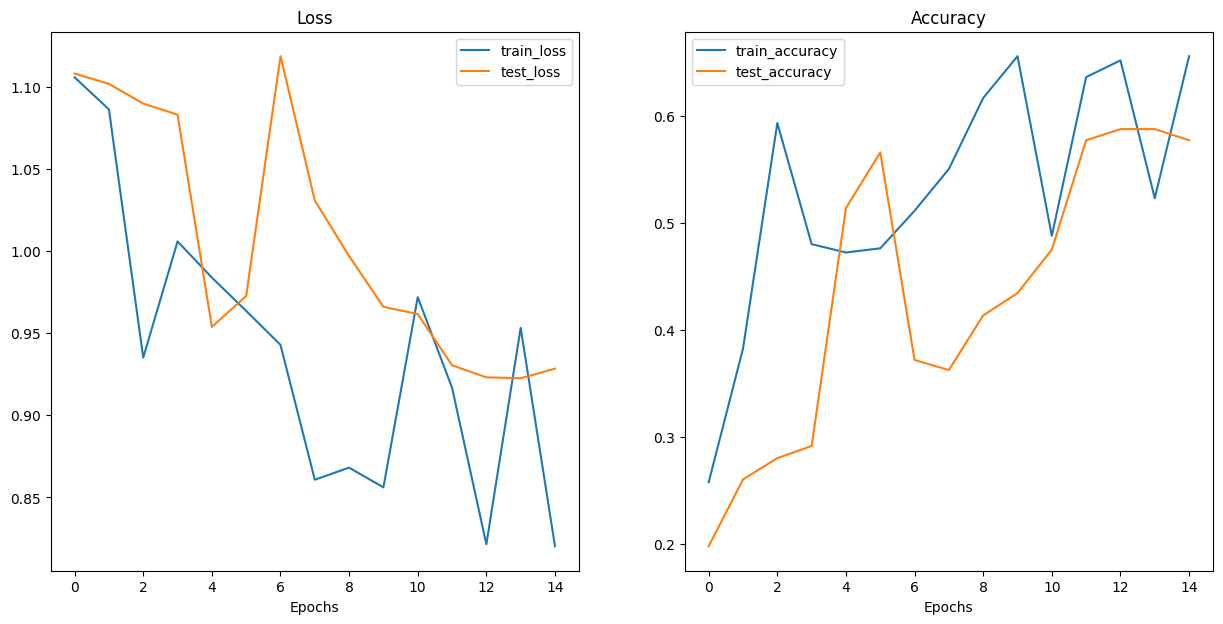

In [81]:
# Plot the loss curves
def plot_loss_curves(results):
    """Plots training curves of a results dictionary."""
    loss = results["train_loss"]
    test_loss = results["test_loss"]

    accuracy = results["train_acc"]
    test_accuracy = results["test_acc"]

    epochs = range(len(results["train_loss"]))

    plt.figure(figsize=(15, 7))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label="train_loss")
    plt.plot(epochs, test_loss, label="test_loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label="train_accuracy")
    plt.plot(epochs, test_accuracy, label="test_accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend()

# Plot the loss curves of our model
plot_loss_curves(model_results)

## 6.3 Making Predictions with our Trained Model

Now that our model is trained, let's use it to make predictions on some test images and see how well it performs.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5877128].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.2710083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.2710083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..2.2885156].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..2.288515

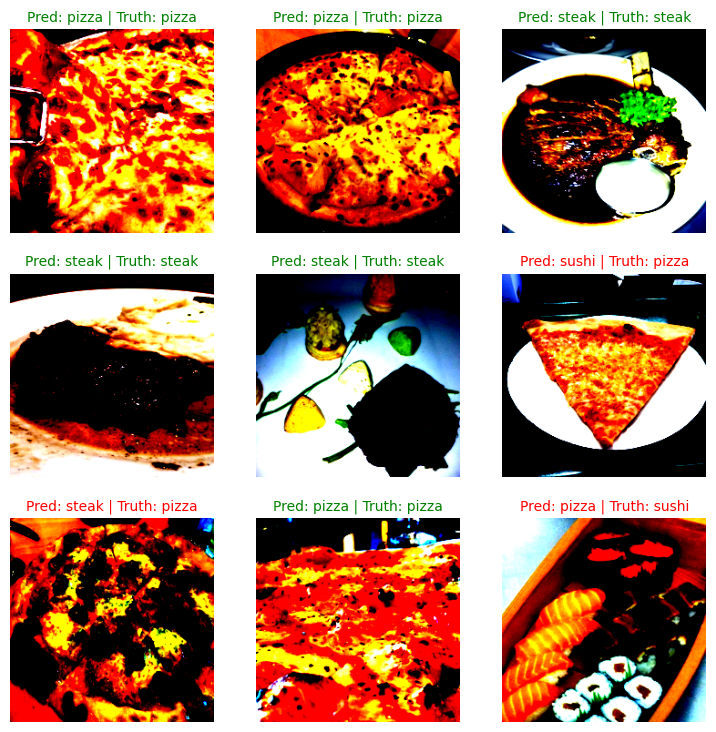

In [82]:
def make_predictions(model: torch.nn.Module, data: list, device: torch.device = device):
    """Makes predictions on data using model."""
    pred_probs = []
    model.eval()
    with torch.inference_mode():
        for sample in data:
            # Prepare sample
            sample = torch.unsqueeze(sample, dim=0).to(device) # Add an extra dimension and send sample to device

            # Forward pass (model outputs raw logit)
            pred_logit = model(sample)

            # Get prediction probability (logit -> prediction probability)
            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0) # note: perform softmax on the "logits" dimension, not "batch" dimension (in this case we have a batch size of 1, so can perform on dim=0)

            # Get pred_prob off GPU for further calculations
            pred_probs.append(pred_prob.cpu())
            
    # Stack the pred_probs to turn list into a tensor
    return torch.stack(pred_probs)

import random
random.seed(42)

# 1. Get a batch of images and labels from the test set
test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), k=9):
    test_samples.append(sample)
    test_labels.append(label)

# 2. Make predictions on test samples with our model
pred_probs = make_predictions(model=model, 
                             data=test_samples)

# 3. Get prediction labels from prediction probabilities
pred_classes = pred_probs.argmax(dim=1)

# 4. Plot predictions
plt.figure(figsize=(9, 9))
nrows = 3
ncols = 3
for i, sample in enumerate(test_samples):
  # Create a subplot
  plt.subplot(nrows, ncols, i+1)

  # Plot the target image
  plt.imshow(sample.permute(1, 2, 0))

  # Find the prediction label (in text form, e.g. "pizza")
  pred_label = class_names[pred_classes[i]]

  # Get the truth label (in text form, e.g. "pizza")
  truth_label = class_names[test_labels[i]] 

  # Create the title text of the plot
  title_text = f"Pred: {pred_label} | Truth: {truth_label}"
  
  # Check for equality and change title colour accordingly
  if pred_label == truth_label:
      plt.title(title_text, fontsize=10, c="g") # green text if correct
  else:
      plt.title(title_text, fontsize=10, c="r") # red text if wrong
  plt.axis(False)

In [83]:
# Calculate final test accuracy
from sklearn.metrics import accuracy_score
import torchmetrics

# Setup confusion matrix
confmat = torchmetrics.ConfusionMatrix(num_classes=len(class_names), task="multiclass")
y_preds = []
model.eval()
with torch.inference_mode():
  for X, y in test_dataloader:
    X, y = X.to(device), y.to(device)
    y_logit = model(X)
    y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1)
    y_preds.append(y_pred.cpu())
y_pred_tensor = torch.cat(y_preds)

# Print final results
print("FoodVision CNN Model Summary:")
print("="*50)
print(f"Model Architecture: Custom CNN with {sum(p.numel() for p in model.parameters()):,} parameters")
print(f"Training Epochs: {NUM_EPOCHS}")
print(f"Final Training Accuracy: {model_results['train_acc'][-1]:.4f}")
print(f"Final Test Accuracy: {model_results['test_acc'][-1]:.4f}")
print(f"Final Training Loss: {model_results['train_loss'][-1]:.4f}")
print(f"Final Test Loss: {model_results['test_loss'][-1]:.4f}")
print(f"Classes: {class_names}")
print("="*50)

FoodVision CNN Model Summary:
Model Architecture: Custom CNN with 6,790,531 parameters
Training Epochs: 15
Final Training Accuracy: 0.6562
Final Test Accuracy: 0.5777
Final Training Loss: 0.8203
Final Test Loss: 0.9284
Classes: ['pizza', 'steak', 'sushi']
